In [88]:
import datetime as dt
import json
import math
import os

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from tqdm import tqdm

from utils_data_vis import *
from utils_graphs import *

plt.style.use("seaborn-v0_8-colorblind")

In [89]:
datasets_folder = "datasets/csvs/"
graphs_folder = "graphs/"
measures_folder = "measures/"
plots_folder = "plots/latex/"

# Horas críticas (Beiró & Gandica et al.)
HORA_CRITICA_NAT, HORA_CRITICA_9N, HORA_CRITICA_CH = "429624", "437037", "394717"
hour_window_nat, hour_window_9n, hour_window_ch = 1, 2, 2

limites = True

# AUTOSIMILITUD EN LAS REDES

## Grafos Filtrados

### Creación de los grafos filtrados

In [90]:
# Threshold empleado para cada manifestacion
umbral_nat = 3
umbral_9n = 5
umbral_ch = 3

# CREACIÓN DE LOS GRAFOS FILTRADOS
write_filtered_graph("nat", HORA_CRITICA_NAT, umbral_nat, graphs_folder, hour_window_nat)
write_filtered_graph("9n", HORA_CRITICA_9N, umbral_9n, graphs_folder, hour_window_9n)
write_filtered_graph("ch", HORA_CRITICA_CH, umbral_ch, graphs_folder, hour_window_ch)

Grafo nat:429624  (umbral 3) reducido a 19.16 % en nodos (123) y  16.85 % en aristas (753). Average degree: 12.24390243902439. Clustering coefficient: 0.8022054707569485.
Grafo 9n:437037  (umbral 5) reducido a 12.58 % en nodos (167) y  7.1 % en aristas (1541). Average degree: 18.45508982035928. Clustering coefficient: 0.7657710923824971.
Grafo ch:394717  (umbral 3) reducido a 13.31 % en nodos (119) y  7.4 % en aristas (271). Average degree: 4.554621848739496. Clustering coefficient: 0.508013218753593.


In [91]:
MAX_UMBRAL = 200
dict_avg_deg_nat_f = get_avg_deg_kt("nat", HORA_CRITICA_NAT, hour_window=hour_window_nat, node_type="filtered", MAX_UMBRAL=MAX_UMBRAL, umbral_filt=umbral_nat)
dict_avg_deg_9n_f = get_avg_deg_kt("9n", HORA_CRITICA_9N, hour_window=hour_window_9n, node_type="filtered", MAX_UMBRAL=MAX_UMBRAL, umbral_filt=umbral_9n)
dict_avg_deg_ch_f = get_avg_deg_kt("ch", HORA_CRITICA_CH, hour_window=hour_window_ch, node_type="filtered", MAX_UMBRAL=MAX_UMBRAL, umbral_filt=umbral_ch)

 19%|█▉        | 38/200 [00:00<00:00, 11005.63it/s]


In [92]:
limit_kt_nat_f, limit_kt_9n_f, limit_kt_ch_f = 35, 60, 30
critical_kt_nat_f, critical_kt_9n_f, critical_kt_ch_f = 10, 18, 5
arr_kt_plot_nat_f = [0, 2, 4, 6, 8, 10]
arr_kt_plot_9n_f = [0, 3, 6, 9, 12, 15, 18]
arr_kt_plot_ch_f = [0, 1, 2, 3, 4, 5]


In [93]:
def calc_exponent_all_dist_deg(hour, manifestacion, graphs_folder="graphs/", mode="h", measures_folder="measures/", G=None, arr_kt=[0], exp=False, read=True, write=True, norm=True, thresh_filt=5):
	
	if mode == "h":
		path_graph = "nodes_hashtag/"
	elif mode == "f":
		path_graph = "nodes_filtered/" + str(thresh_filt) + '/'
	
	G = nx.read_gexf(graphs_folder + path_graph + manifestacion + hour + '.gexf')
		
	arr_points = []
	dict_points = {}
	measures_path = measures_folder + manifestacion + hour + '_' + mode + '_degs_kt.json'
	if read:
		if os.path.exists(measures_path):
			try:
				with open(measures_path, '') as f:
					dict_points = json.load(f)
				dict_points = convert_keys_to_float(dict_points, tipo="int")
			except json.JSONDecodeError:
				pass
	
	for kt in tqdm(arr_kt):
		points_kt = [0]
		if not kt in dict_points.keys():
			F = thresh_normalization(G, kt)
			if F != -1:
				points_kt = np.sort(np.array(list(dict(F.degree()).values())).astype(float))
				dict_points[kt] = list(points_kt)
		else:
			points_kt = dict_points[kt]
		if norm:
			points_kt = np.array(points_kt) / np.mean(points_kt)
		arr_points.append(points_kt)

	points = []
	for kt in arr_kt:
		points_kt = dict_points[kt]
		for p in points_kt:
			points.append(p)

	plfit = get_exp(points)
	return plfit


def calc_exponent_all_dist_clust(dict_norm_int_deg, arr_kt):
	points = []
	for kt in arr_kt:
		norm_int_deg_kt = dict_norm_int_deg[kt]
		for c in norm_int_deg_kt:
			points.append(c)
	plfit = get_exp(points)
	return plfit

In [94]:
def _exp_bin_xy(x, y, aa=1.02, normalize=False):
    """Binning exponencial (x,y) con centro geométrico."""
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    m = (x > 0) & np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]
    if x.size == 0:
        return np.array([]), np.array([])

    xmax = float(x.max())
    xs, ys = [], []
    i = 1
    while aa**i <= xmax:
        lo, hi = aa**i, aa ** (i + 1)
        if float(int(lo)) == lo:
            lo -= 0.1
        if float(int(hi)) == hi:
            hi += 0.1

        sel = (x > lo) & (x <= hi)
        if np.any(sel):
            xg = math.sqrt(lo * hi)
            yb = y[sel].sum() / (hi - lo) if normalize else y[sel].mean()
            xs.append(xg)
            ys.append(yb)
        i += 1

    return np.array(xs), np.array(ys)


def _exp_bin_xy_ss(x, y, aa=1.02):
    """Binning exponencial (x,y) para self-sim (media por bin)."""
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    m = (x > 0) & np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]
    if x.size == 0:
        return np.array([]), np.array([])

    xmax = float(x.max())
    xs, ys = [], []
    i = 1
    while aa**i <= xmax:
        lo, hi = aa**i, aa ** (i + 1)
        if float(int(lo)) == lo:
            lo -= 0.1
        if float(int(hi)) == hi:
            hi += 0.1

        sel = (x > lo) & (x <= hi)
        if np.any(sel):
            xs.append(math.sqrt(lo * hi))
            ys.append(y[sel].mean())
        i += 1

    return np.array(xs), np.array(ys)


def _densprob_exp_bin_xy_ss(x, y, nobinning=0, aa=1.02, ncajas=None, xf=None):
    """
    Exponential binning estilo `DensProbBinning.py` para self-sim (x,y).

    - Para x <= nobinning: deja los puntos "exactos".
    - Para x > nobinning: agrupa en cajas exponenciales.
      Centro del bin = media aritmética de x dentro del bin (como en DensProbBinning).
      Valor del bin   = media de y dentro del bin.

    Parámetros:
    - nobinning: umbral de binning exacto.
    - aa: factor de crecimiento (equivale a xq si usas x0=1).
    - ncajas / xf: si no se dan, se infieren desde el máximo de x.

    Devuelve (xb, yb).
    """
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    m = (x > 0) & np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]
    if x.size == 0:
        return np.array([]), np.array([])

    nobinning = int(nobinning)

    # En `DensProbBinning.py` el binning exponencial empieza en x0=nobinning+1.
    # Aquí, cuando trabajamos con x continuo (p.ej. valores normalizados <1),
    # usar x0=1 eliminaría todos los puntos en (0,1). Por eso, si nobinning<=0
    # arrancamos el binning en el mínimo x>0 observado.
    if nobinning <= 0:
        x0 = float(np.min(x[x > 0]))
    else:
        x0 = float(nobinning) + 1.0

    # Parte exacta
    exact = x <= nobinning
    xb_exact = x[exact]
    yb_exact = y[exact]
    if xb_exact.size:
        order = np.argsort(xb_exact)
        xb_exact = xb_exact[order]
        yb_exact = yb_exact[order]

    # Parte exponencial (cajas)
    xe = x[~exact]
    ye = y[~exact]
    if xe.size == 0:
        return xb_exact, yb_exact

    if xf is None:
        xf = float(xe.max())
    else:
        xf = float(xf)

    if xf <= x0:
        return xb_exact, yb_exact

    if ncajas is None:
        # Número de cajas para cubrir hasta xf con factor aa
        ncajas = int(math.floor(math.log(xf / x0) / math.log(float(aa))))
        ncajas = max(ncajas, 1)
    else:
        ncajas = int(ncajas)
        ncajas = max(ncajas, 1)

    xq = float(aa)

    xs, ys = [], []
    for i in range(1, ncajas + 1):
        lo = x0 * (xq ** (i - 1))
        hi = x0 * (xq ** i)
        sel = (xe > lo) & (xe <= hi)
        if np.any(sel):
            xs.append(float(xe[sel].mean()))
            ys.append(float(ye[sel].mean()))

    xb = np.concatenate([xb_exact, np.asarray(xs)]) if len(xs) else xb_exact
    yb = np.concatenate([yb_exact, np.asarray(ys)]) if len(ys) else yb_exact

    return xb, yb


def plot_clust_ss_densprob_expbin(
    ax,
    arr_kt_plot,
    dict_norm_int_deg,
    aa=1.02,
    nobinning=0,
    ncajas=None,
    xf=None,
    xlim=None,
    ylim=(0.01, 1.05),
    alpha=0.7,
    marker="x",
    linewidth=0.8,
    s=10,
    legend=True,
    loc=None,
    title=None,
    ylabel=None,
    xlabel=None,
):
    """Plot tipo `plot_clust_ss_expbin`, pero con binning estilo `DensProbBinning.py`."""
    for kt in arr_kt_plot:
        if kt not in dict_norm_int_deg:
            continue

        x_vals = np.array(list(dict_norm_int_deg[kt].keys()), dtype=float)
        y_vals = np.array(list(dict_norm_int_deg[kt].values()), dtype=float)

        m = (x_vals > 0) & np.isfinite(x_vals) & np.isfinite(y_vals) & (y_vals > 0)
        x_vals = x_vals[m]
        y_vals = y_vals[m]
        if x_vals.size == 0:
            continue

        xb, yb = _densprob_exp_bin_xy_ss(
            x_vals,
            y_vals,
            nobinning=nobinning,
            aa=aa,
            ncajas=ncajas,
            xf=xf,
        )
        m2 = (xb > 0) & (yb > 0) & np.isfinite(xb) & np.isfinite(yb)
        xb = xb[m2]
        yb = yb[m2]
        if xb.size == 0:
            continue

        ax.plot(xb, yb, alpha=alpha, linewidth=linewidth, marker=marker, ms=s)
        ax.scatter(xb, yb, alpha=alpha, s=20, marker=marker, label=f'$k_T: {kt}$')

    ax.set_xscale('log')
    ax.set_yscale('log')

    if title:
        ax.set_title(title, fontsize=20)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=20)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=20)

    if ylim:
        ax.set_ylim(ylim[0], ylim[1])
    if xlim:
        ax.set_xlim(xlim[0], xlim[1])

    if legend:
        if loc:
            ax.legend(loc=loc, prop={'size': 12})
        else:
            ax.legend(prop={'size': 12})


In [95]:
def calc_exponentes(arr_ccdf_points, arr_kt_plot, dict_norm_int_deg):
	arr_x = []
	arr_y = []
	for idx, (x, y) in enumerate(arr_ccdf_points):
			xb, yb = _exp_bin_xy(x, y, aa=1.02, normalize=False)
			if xb.size == 0:
				continue

			# Filtrar puntos problemáticos (y <= 0) para escala log
			mask = yb > 0
			xb = xb[mask]
			yb = yb[mask]
			if xb.size == 0:
				continue
			
			for x_elem in xb:
				arr_x.append(x_elem)
			for y_elem in yb:
				arr_y.append(y_elem)


	arr_x = np.array(arr_x, dtype=float)
	arr_y = np.array(arr_y, dtype=float)
	mask = (arr_x > 0) & (arr_y > 0)   # para evitar log(0) o log de negativos
	logx = np.log10(arr_x[mask])
	logy = np.log10(arr_y[mask])
	m, b = np.polyfit(logx, logy, 1)  # m = pendiente, b = intercepto
	print("Degree")
	print("Pendiente (alpha):", m)
	print("Logaritmo de A:", b)

	"""data = np.repeat(arr_x, arr_y.astype(int))

	print(arr_x, arr_y,data)
	# Si los datos son discretos (normal en este caso):
	fit = powerlaw.Fit(data, discrete=True)

	alpha = fit.power_law.alpha
	xmin  = fit.power_law.xmin
	print("Estimated alpha:", alpha, "xmin:", xmin)"""

	arr_x = []
	arr_y = []
	for kt in arr_kt_plot:
			if kt not in dict_norm_int_deg:
				continue

			# Extraer pares (grado, valor)
			# Nota: dict puede no estar ordenado; para el binning no hace falta orden.
			x_vals = np.array(list(dict_norm_int_deg[kt].keys()), dtype=float)
			y_vals = np.array(list(dict_norm_int_deg[kt].values()), dtype=float)

			# Limpiar: quitar grado=0 y no finitos; también y<=0 si vas a usar escala log en Y
			m = (x_vals > 0) & np.isfinite(x_vals) & np.isfinite(y_vals) & (y_vals > 0)
			x_vals = x_vals[m]; y_vals = y_vals[m]
			if x_vals.size == 0:
				continue

			xb, yb = _exp_bin_xy_ss(x_vals, y_vals, aa=1.02)
			if xb.size == 0:
				continue

			for x_elem in xb:
				arr_x.append(x_elem)
			for y_elem in yb:
				arr_y.append(y_elem)

	arr_x = np.array(arr_x, dtype=float)
	arr_y = np.array(arr_y, dtype=float)
	mask = (arr_x > 0) & (arr_y > 0)   # para evitar log(0) o log de negativos
	logx = np.log10(arr_x[mask])
	logy = np.log10(arr_y[mask])
	m, b = np.polyfit(logx, logy, 1)  # m = pendiente, b = intercepto

	print("Clustering")
	print("Pendiente (alpha):", m)
	print("Logaritmo de A::", b)


	"""data = np.repeat(arr_x, arr_y.astype(int))

	# Si los datos son discretos (normal en este caso):
	fit = powerlaw.Fit(data, discrete=True)

	alpha = fit.power_law.alpha
	xmin  = fit.power_law.xmin
	print("Estimated alpha:", alpha, "xmin:", xmin)"""

In [96]:
def calc_exponent_all_dist_deg(hour, manifestacion, graphs_folder="graphs/", mode="h", measures_folder="measures/", G=None, arr_kt=[0], exp=False, read=True, write=True, norm=True, thresh_filt=5):
	
	if mode == "h":
		path_graph = "nodes_hashtag/"
	elif mode == "f":
		path_graph = "nodes_filtered/" + str(thresh_filt) + '/'
	
	G = nx.read_gexf(graphs_folder + path_graph + manifestacion + hour + '.gexf')
		
	arr_points = []
	dict_points = {}
	measures_path = measures_folder + manifestacion + hour + '_' + mode + '_degs_kt.json'
	if read:
		if os.path.exists(measures_path):
			try:
				with open(measures_path, '') as f:
					dict_points = json.load(f)
				dict_points = convert_keys_to_float(dict_points, tipo="int")
			except json.JSONDecodeError:
				pass
	
	for kt in tqdm(arr_kt):
		points_kt=[0]
		if not kt in dict_points.keys():
			F = thresh_normalization(G, kt)
			if F != -1:
				points_kt = np.sort(np.array(list(dict(F.degree()).values())).astype(float))
				dict_points[kt] = list(points_kt)
				"""for index, point in enumerate(points_kt):
					if kt== 0:
						print(kt, point, ':', point / np.mean(points_kt), sorted(F.nodes[node]["internalDegree"] for node in F.nodes())[index])"""
	
		else:
			points_kt = dict_points[kt]
		if norm:
			points_kt = np.array(points_kt) / np.mean(points_kt)
		arr_points.append(points_kt)
	plfit = None

	points = []
	for kt in arr_kt:
		points_kt = dict_points[kt]
		for p in points_kt:
			points.append(p)

	plfit = get_exp(points)
	return plfit


In [97]:
def plot_ccdf(ax, arr_deg_prob, arr_kt_plot, title=None, ylabel="P(X>x)", ylim=(0.0002, 1.05), xlim=None, marker= "o", alpha=1, dot_size=30):
	if title:
		ax.set_title(title, fontsize=20)
	for index, points in enumerate(arr_deg_prob):
		ax.scatter(points[0][:-1], points[1][:-1], marker=marker, s=dot_size, alpha=alpha, label=f"$k_t :$ {str(arr_kt_plot[index])}")
		ax.plot(points[0][:-1], points[1][:-1], alpha=1, linewidth=1.5)
	ax.set_xscale('log')
	ax.set_yscale('log')
	if ylim:
		ax.set_ylim(ylim[0], ylim[1])
	if xlim:
		ax.set_xlim(xlim[0], xlim[1])
	if ylabel:
		ax.set_ylabel(ylabel, fontsize=20)

def plot_avg_deg(ax, dict_avg_de, limit_kt, axvline=None, xlabel=None, ylabel=None, alpha=0.7, dot_size=6, ylim=None):
	ax.set_facecolor('xkcd:white')
	for spine in ax.spines.values():
		spine.set_visible(True)  # Asegurar que sea visible
		spine.set_linewidth(0.5)   # Grosor del borde (opcional)
		spine.set_color("black") 
	ax.get_xaxis().set_visible(True)
	ax.plot(list(dict_avg_de.keys())[0:limit_kt], list(dict_avg_de.values())[0:limit_kt], alpha=alpha)
	ax.scatter(list(dict_avg_de.keys())[0:limit_kt], list(dict_avg_de.values())[0:limit_kt], s=dot_size, alpha=alpha)
	if ylim:
		ax.set_ylim(ylim[0], ylim[1])
	if axvline:
		ax.axvline(axvline, ls="--")
	if xlabel:
		ax.set_xlabel(xlabel, fontsize=16)
	if ylabel:
		ax.set_ylabel(ylabel, fontsize=16)
	ax.tick_params(axis='both', which='major', labelsize=10)


def plot_avg_clust(ax, dict_thres_avg_clust, ylabel, xlabel, xlim):
	ax.set_facecolor('xkcd:white')
	for spine in ax.spines.values():
		spine.set_visible(True)  # Asegurar que sea visible
		spine.set_linewidth(0.5)   # Grosor del borde (opcional)
		spine.set_color("black") 
	ax.get_xaxis().set_visible(True)
	ax.plot(list(dict_thres_avg_clust.keys())[0:xlim], list(dict_thres_avg_clust.values())[0:xlim])
	ax.scatter(list(dict_thres_avg_clust.keys())[0:xlim], list(dict_thres_avg_clust.values())[0:xlim], s=6)
	if xlabel:
		ax.set_xlabel(xlabel, fontsize=16)
	if ylabel:
		ax.set_ylabel(ylabel, fontsize=16)
	ax.tick_params(axis='both', which='major', labelsize=10)

In [98]:
plfit_nat_f, arr_pdf_points_nat_f, arr_ccdf_points_nat_f = calc_degree_distribution(str(int(HORA_CRITICA_NAT)), "nat/" + str(hour_window_nat) + '/', mode="f", graphs_folder=graphs_folder, measures_folder=measures_folder, exp=True, arr_kt=arr_kt_plot_nat_f, thresh_filt=umbral_nat, norm=True, read=False)
dict_thres_avg_clust_nat_f, dict_norm_int_deg_nat_f = calc_self_sim(str(int(HORA_CRITICA_NAT)), MAX_UMBRAL, "nat/" + str(hour_window_nat) + '/', mode="f", thresh_filter=umbral_nat)
plfit_9n_f, arr_pdf_points_9n_f, arr_ccdf_points_9n_f = calc_degree_distribution(str(int(HORA_CRITICA_9N)+24), "9n/" + str(hour_window_9n) + '/', mode="f", graphs_folder=graphs_folder, measures_folder=measures_folder, exp=True, arr_kt=arr_kt_plot_9n_f, thresh_filt=umbral_9n, norm=True, read=False)
dict_thres_avg_clust_9n_f, dict_norm_int_deg_9n_f = calc_self_sim(str(int(HORA_CRITICA_9N)+24), MAX_UMBRAL, "9n/" + str(hour_window_9n) + '/', mode="f", thresh_filter=umbral_9n)
plfit_ch_f, arr_pdf_points_ch_f, arr_ccdf_points_ch_f = calc_degree_distribution(str(int(HORA_CRITICA_CH)), "ch/" + str(hour_window_ch) + '/', mode="f", graphs_folder=graphs_folder, measures_folder=measures_folder, exp=True, arr_kt=arr_kt_plot_ch_f, thresh_filt=umbral_ch, norm=True, read=False)
dict_thres_avg_clust_ch_f, dict_norm_int_deg_ch_f = calc_self_sim(str(int(HORA_CRITICA_CH)), MAX_UMBRAL, "ch/" + str(hour_window_ch) + '/', mode="f", thresh_filter=umbral_ch)


100%|██████████| 6/6 [00:00<00:00, 987.36it/s]


Calculating best minimal value for power law fit


  0%|          | 0/200 [00:00<?, ?it/s]

100%|██████████| 7/7 [00:00<00:00, 841.58it/s]


Calculating best minimal value for power law fit


100%|██████████| 6/6 [00:00<00:00, 3056.70it/s]


Calculating best minimal value for power law fit


 19%|█▉        | 38/200 [00:00<00:00, 1637.83it/s]


In [99]:
plfit_nat_f = calc_exponent_all_dist_deg(str(int(HORA_CRITICA_NAT)), "nat/" + str(hour_window_nat) + '/', mode="f", graphs_folder=graphs_folder, measures_folder=measures_folder, exp=True, arr_kt=arr_kt_plot_nat_f, thresh_filt=umbral_nat, norm=True, read=False)
plfit_9n_f = calc_exponent_all_dist_deg(str(int(HORA_CRITICA_9N)), "9n/" + str(hour_window_9n) + '/', mode="f", graphs_folder=graphs_folder, measures_folder=measures_folder, exp=True, arr_kt=arr_kt_plot_9n_f, thresh_filt=umbral_9n, norm=True, read=False)
plfit_ch_f = calc_exponent_all_dist_deg(str(int(HORA_CRITICA_CH)), "ch/" + str(hour_window_ch) + '/', mode="f", graphs_folder=graphs_folder, measures_folder=measures_folder, exp=True, arr_kt=arr_kt_plot_ch_f, thresh_filt=umbral_ch, norm=True, read=False)

plfit_clust_nat_f = calc_exponent_all_dist_clust(dict_norm_int_deg_nat_f, arr_kt_plot_nat_f)
plfit_clust_9n_f = calc_exponent_all_dist_clust(dict_norm_int_deg_9n_f, arr_kt_plot_9n_f)
plfit_clust_ch_f = calc_exponent_all_dist_clust(dict_norm_int_deg_ch_f, arr_kt_plot_ch_f)

100%|██████████| 6/6 [00:00<00:00, 970.79it/s]


Calculating best minimal value for power law fit


100%|██████████| 7/7 [00:00<00:00, 467.80it/s]


Calculating best minimal value for power law fit


100%|██████████| 6/6 [00:00<00:00, 2864.31it/s]

Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit


In [100]:
print("NAT")
print(f"Alpha degree: {plfit_nat_f.alpha}\nAlpha clustering: {plfit_clust_nat_f.alpha}")
print("9n")
print(f"Alpha degree: {plfit_9n_f.alpha}\nAlpha clustering: {plfit_clust_9n_f.alpha}")
print("Charlie Hebdo")
print(f"Alpha degree: {plfit_ch_f.alpha}\nAlpha clustering: {plfit_clust_ch_f.alpha}")

NAT
Alpha degree: 3.4742744865870123
Alpha clustering: 2.828058694037268
9n
Alpha degree: 4.542105675824008
Alpha clustering: 3.8118935526527586
Charlie Hebdo
Alpha degree: 2.9975681205753544
Alpha clustering: 2.4914710126348414


In [101]:
def get_minus_one_dict(dict_norm_int_deg):
	dict_aux = {}
	for k in dict_norm_int_deg.keys():
		dict_aux[k] = {}
		len_k = len(dict_norm_int_deg[k])
		i = 1
		for degree, value in dict_norm_int_deg[k].items():
			if i <len_k:
				dict_aux[k][degree] = value
			i += 1
	return dict_aux


In [102]:
"""dict_norm_int_deg_nat_f = get_minus_one_dict(dict_norm_int_deg_nat_f)
dict_norm_int_deg_9n_f = get_minus_one_dict(dict_norm_int_deg_9n_f)
dict_norm_int_deg_ch_f = get_minus_one_dict(dict_norm_int_deg_ch_f)"""

'dict_norm_int_deg_nat_f = get_minus_one_dict(dict_norm_int_deg_nat_f)\ndict_norm_int_deg_9n_f = get_minus_one_dict(dict_norm_int_deg_9n_f)\ndict_norm_int_deg_ch_f = get_minus_one_dict(dict_norm_int_deg_ch_f)'

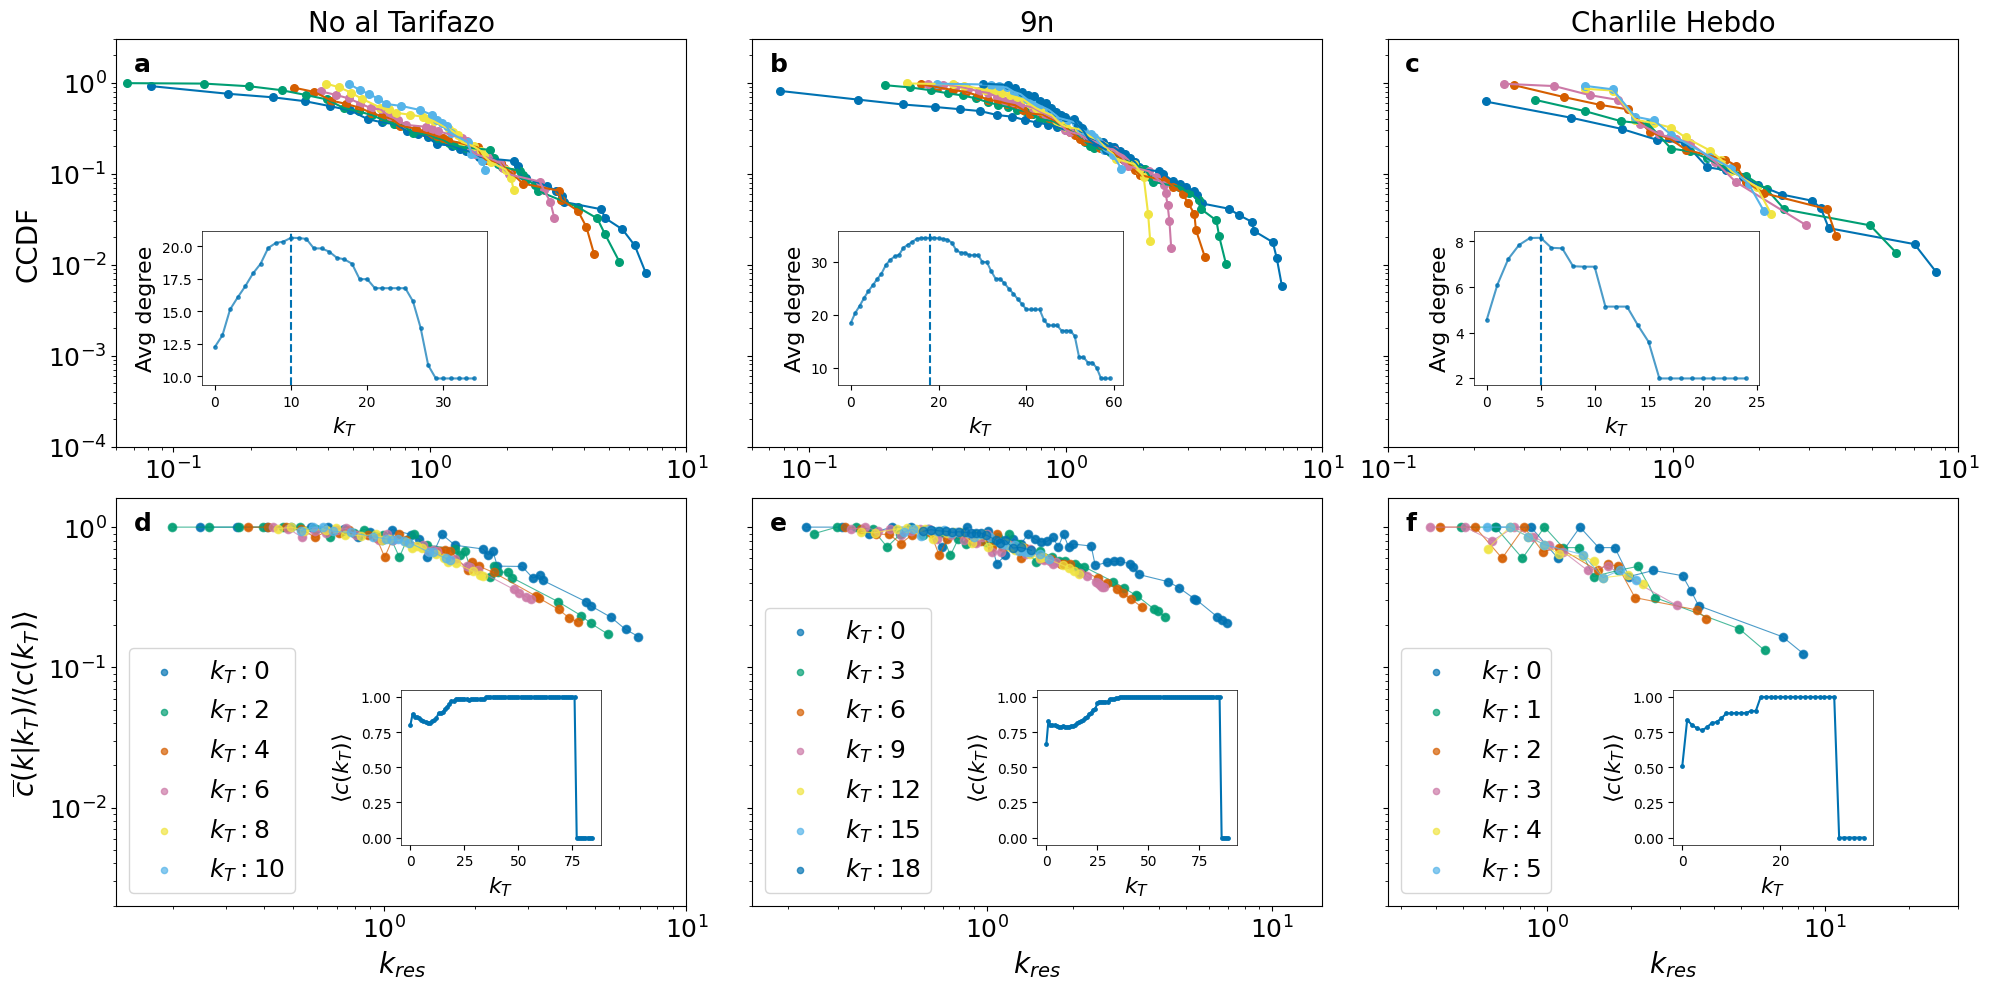

In [103]:
plt.style.use('seaborn-v0_8-colorblind')    
from matplotlib.ticker import MaxNLocator

fig, axs = plt.subplots(2, 3)
axs = axs.flat
for ax in axs:  
	ax.set_facecolor("white")
fig.set_size_inches(20,10)


plot_ccdf(axs[0], arr_ccdf_points_nat_f, arr_kt_plot_nat_f, ylim=(0.0001, 3), xlim=(0.06,10))
ax0_inset = axs[0].inset_axes([0.15, 0.15, 0.5, 0.38])
plot_avg_deg(ax0_inset, dict_avg_deg_nat_f, limit_kt_nat_f, axvline=critical_kt_nat_f, xlabel="$k_T$", ylabel="Avg degree")

plot_clust_ss_densprob_expbin(axs[3], arr_kt_plot_nat_f, dict_norm_int_deg_nat_f,
                             aa=1.02, nobinning=0.1, xlim=(0.13, 10), ylim=(0.002, 1.6),
                             alpha=0.7, marker="o", linewidth=0.8, s=6,
                             ylabel="$\\overline{c}(k|k_T)/\\langle c(k_T)\\rangle$", xlabel="$k_{res}$")
ax3_inset = axs[3].inset_axes([0.5, 0.15, 0.35, 0.38])
plot_avg_clust(ax3_inset, dict_thres_avg_clust_nat_f, ylabel="$\\langle c(k_T)\\rangle$", xlabel="$k_T$", xlim=100)



plot_ccdf(axs[1], arr_ccdf_points_9n_f, arr_kt_plot_9n_f, ylim=(0.0001, 3), xlim=(0.06,10))
ax1_inset = axs[1].inset_axes([0.15, 0.15, 0.5, 0.38])
plot_avg_deg(ax1_inset, dict_avg_deg_9n_f, limit_kt_9n_f, axvline=critical_kt_9n_f, xlabel="$k_T$", ylabel="Avg degree")

plot_clust_ss_densprob_expbin(axs[4], arr_kt_plot_9n_f, dict_norm_int_deg_9n_f,
                             aa=1.02, nobinning=0, xlim=(0.15, 15), ylim=(0.002, 1.6),
                             alpha=0.7, marker="o", linewidth=0.8, s=6,
                             ylabel="$\\overline{c(Q_n(k_T))}$", xlabel="$k_{res}$")
ax4_inset = axs[4].inset_axes([0.5, 0.15, 0.35, 0.38])
plot_avg_clust(ax4_inset, dict_thres_avg_clust_9n_f, ylabel="$\\langle c(k_T)\\rangle$", xlabel="$k_T$", xlim=100)



plot_ccdf(axs[2], arr_ccdf_points_ch_f, arr_kt_plot_ch_f, ylim=(0.0001, 3), xlim=(0.1,10))
ax2_inset = axs[2].inset_axes([0.15, 0.15, 0.5, 0.38])
plot_avg_deg(ax2_inset, dict_avg_deg_ch_f, 25, axvline=critical_kt_ch_f, xlabel="$k_T$", ylabel="Avg degree")

plot_clust_ss_densprob_expbin(axs[5], arr_kt_plot_ch_f, dict_norm_int_deg_ch_f,
                             aa=1.02, nobinning=0, xlim=(0.27, 30), ylim=(0.002, 1.6),
                             alpha=0.7, marker="o", linewidth=0.8, s=6,
                             ylabel="$\\overline{c(Q_n(k_T))}$", xlabel="$k_{res}$")

					 
ax5_inset = axs[5].inset_axes([0.5, 0.15, 0.35, 0.38])
plot_avg_clust(ax5_inset, dict_thres_avg_clust_ch_f, ylabel="$\\langle c(k_T)\\rangle$", xlabel="$k_T$", xlim=50)




letters_plot = ['a', 'b', 'c', 'd', 'e', 'f']
for index, ax in enumerate(axs):
	ax.text(0.03, 0.97, letters_plot[index], transform=ax.transAxes, fontsize=18, fontweight="bold",va="top",ha="left")

axs[3].legend(fontsize=18, loc="lower left")
axs[4].legend(fontsize=18, loc="lower left")
axs[5].legend(fontsize=18, loc="lower left")

for ax in axs:
	ax.tick_params(axis='both', which='major', labelsize=18)  
axs[0].set_ylabel("CCDF", fontsize=20)

no_lab = [1,2,4,5]
for no in no_lab:
	axs[no].set_ylabel("")
	axs[no].set_yticklabels([])

axs[0].set_title("No al Tarifazo", fontsize=20)
axs[1].set_title("9n", fontsize=20)
axs[2].set_title("Charlile Hebdo", fontsize=20)

plt.tight_layout()
#plt.savefig(plots_folder + "all_self_sim_exponential_filtered.png", dpi=1000)
plt.show()

## Redes filtradas otras horas

In [104]:
def find_col(df, candidates):
    for cand in candidates:
        for col in df.columns:
            if col.strip() == cand.strip():
                return col
    return None

df = pd.read_csv("epsilon_sq/ch/results/Epsilon_values.txt", sep="\t")
df.columns = [c.strip() for c in df.columns]


# Map raw headers → internal names (the originals use undefined \ccdf, \knn, \cco)
rename_map = {
	"$\epsilon_{\ccdf}$": "eps_ccdf",
	"$\epsilon_{\knn}$":  "eps_knn",
	"$\epsilon_{\cco}$":  "eps_cco",
}
# If columns already simple, this won't change anything
df = df.rename(columns=rename_map)


def rolling_mean_centrada(series):
	s = pd.to_numeric(series, errors="coerce")
	# Promedia [i-1, i, i+1]; en bordes usa los disponibles
	return s.rolling(window=3, center=True, min_periods=1).mean()

y_ma = rolling_mean_centrada(df["eps_cco"])
y_ma

<>:14: SyntaxWarning: invalid escape sequence '\e'
<>:15: SyntaxWarning: invalid escape sequence '\e'
<>:16: SyntaxWarning: invalid escape sequence '\e'
<>:14: SyntaxWarning: invalid escape sequence '\e'
<>:15: SyntaxWarning: invalid escape sequence '\e'
<>:16: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_92839/1132637584.py:14: SyntaxWarning: invalid escape sequence '\e'
  "$\epsilon_{\ccdf}$": "eps_ccdf",
/tmp/ipykernel_92839/1132637584.py:15: SyntaxWarning: invalid escape sequence '\e'
  "$\epsilon_{\knn}$":  "eps_knn",
/tmp/ipykernel_92839/1132637584.py:16: SyntaxWarning: invalid escape sequence '\e'
  "$\epsilon_{\cco}$":  "eps_cco",


0     0.265900
1     0.309400
2     0.307867
3     0.457533
4     0.476800
        ...   
76    0.506133
77    0.528000
78    0.374667
79    0.272050
80    0.025000
Name: eps_cco, Length: 81, dtype: float64

In [105]:
# Horas críticas identificadas en el artículo de Beiró and Gandica et al.
HORA_CRITICA_NAT = "429624"
HORA_CRITICA_9N = "437061"
HORA_CRITICA_9N = "437037"
HORA_CRITICA_CH = "394717"

In [106]:
OTRA_HORA_NAT = str(int(HORA_CRITICA_NAT) - 24)   # NAT: 24h before
OTRA_HORA_9N  = str(int(HORA_CRITICA_9N) - 48)    # 9N:  48h before
OTRA_HORA_CH  = str(int(HORA_CRITICA_CH) - 72)    # CH:  72h before

arr_kt_plot_nat_o_f = [0, 2, 4, 6, 8, 10]
arr_kt_plot_9n_o_f  = [0, 3, 6, 9, 12, 15, 18]
arr_kt_plot_ch_o_f  = [0, 2, 4, 6, 8, 10]

umbral_nat_o, umbral_9n_o, umbral_ch_o = 1, 3, 1
limit_kt_nat_o_f, limit_kt_9n_o_f, limit_kt_ch_o_f = 60, 150, 60


In [107]:
# CREACIÓN DE LOS GRAFOS FILTRADOS
write_filtered_graph("nat", OTRA_HORA_NAT, umbral_nat_o, graphs_folder, hour_window_nat)
write_filtered_graph("9n", OTRA_HORA_9N, umbral_9n_o, graphs_folder, hour_window_9n)
write_filtered_graph("ch", OTRA_HORA_CH, umbral_ch_o, graphs_folder, hour_window_ch)


# MAX_UMBRAL es el máximo K_T que se va a usar para generar subgrafos
MAX_UMBRAL = 200
dict_avg_deg_nat_o_f = get_avg_deg_kt("nat", OTRA_HORA_NAT, hour_window=hour_window_nat, node_type="filtered", MAX_UMBRAL=MAX_UMBRAL, umbral_filt=umbral_nat_o)
dict_avg_deg_9n_o_f = get_avg_deg_kt("9n", OTRA_HORA_9N, hour_window=hour_window_9n, node_type="filtered", MAX_UMBRAL=MAX_UMBRAL, umbral_filt=umbral_9n_o)
dict_avg_deg_ch_o_f = get_avg_deg_kt("ch", OTRA_HORA_CH, hour_window=hour_window_ch, node_type="filtered", MAX_UMBRAL=MAX_UMBRAL, umbral_filt=umbral_ch_o)

plfit_nat_o_f, arr_pdf_points_nat_o_f, arr_ccdf_points_nat_o_f = calc_degree_distribution(str(int(OTRA_HORA_NAT)), "nat/" + str(hour_window_nat) + '/', mode="f", graphs_folder=graphs_folder, measures_folder=measures_folder, exp=True, arr_kt=arr_kt_plot_nat_o_f, thresh_filt=umbral_nat_o, norm=True, read=False)
dict_thres_avg_clust_nat_o_f, dict_norm_int_deg_nat_o_f = calc_self_sim(str(int(OTRA_HORA_NAT)), MAX_UMBRAL, "nat/" + str(hour_window_nat) + '/', mode="f", thresh_filter=umbral_nat_o)

plfit_9n_o_f, arr_pdf_points_9n_o_f, arr_ccdf_points_9n_o_f = calc_degree_distribution(str(int(OTRA_HORA_9N)), "9n/" + str(hour_window_9n) + '/', mode="f", graphs_folder=graphs_folder, measures_folder=measures_folder, exp=True, arr_kt=arr_kt_plot_9n_o_f, thresh_filt=umbral_9n_o, norm=True, read=False)
dict_thres_avg_clust_9n_o_f, dict_norm_int_deg_9n_o_f = calc_self_sim(str(int(OTRA_HORA_9N)), MAX_UMBRAL, "9n/" + str(hour_window_9n) + '/', mode="f", thresh_filter=umbral_9n_o)

plfit_ch_o_f, arr_pdf_points_ch_o_f, arr_ccdf_points_ch_o_f = calc_degree_distribution(str(int(OTRA_HORA_CH)), "ch/" + str(hour_window_ch) + '/', mode="f", graphs_folder=graphs_folder, measures_folder=measures_folder, exp=True, arr_kt=arr_kt_plot_ch_o_f, thresh_filt=umbral_ch_o, norm=True, read=False)
dict_thres_avg_clust_ch_o_f, dict_norm_int_deg_ch_o_f = calc_self_sim(str(int(OTRA_HORA_CH)), MAX_UMBRAL, "ch/" + str(hour_window_ch) + '/', mode="f", thresh_filter=umbral_ch_o)

Grafo nat:429600  (umbral 1) reducido a 47.71 % en nodos (219) y  79.71 % en aristas (1006). Average degree: 9.187214611872147. Clustering coefficient: 0.7791071718625731.
Grafo 9n:436989  (umbral 3) reducido a 9.97 % en nodos (116) y  6.19 % en aristas (492). Average degree: 8.482758620689655. Clustering coefficient: 0.5720344557695168.
Grafo ch:394645  (umbral 1) reducido a 55.7 % en nodos (249) y  73.2 % en aristas (1005). Average degree: 8.072289156626505. Clustering coefficient: 0.7444492917960925.


100%|██████████| 6/6 [00:00<00:00, 780.17it/s]


Calculating best minimal value for power law fit


100%|██████████| 7/7 [00:00<00:00, 2036.92it/s]


Calculating best minimal value for power law fit


100%|██████████| 6/6 [00:00<00:00, 900.68it/s]


Calculating best minimal value for power law fit


 63%|██████▎   | 126/200 [00:00<00:00, 688.87it/s]


In [108]:
def get_minus_one_dict(dict_norm_int_deg):
	dict_aux = {}
	for k in dict_norm_int_deg.keys():
		dict_aux[k] = {}
		len_k = len(dict_norm_int_deg[k])
		i = 1
		for degree, value in dict_norm_int_deg[k].items():
			if i <len_k:
				dict_aux[k][degree] = value
			i += 1
	return dict_aux

#dict_norm_int_deg_nat_o_f = get_minus_one_dict(dict_norm_int_deg_nat_o_f)
#dict_norm_int_deg_9n_o_f = get_minus_one_dict(dict_norm_int_deg_9n_o_f)
#dict_norm_int_deg_ch_o_f = get_minus_one_dict(dict_norm_int_deg_ch_o_f)

In [109]:
eps_nat =  0.154867
#eps_nat = eps_nat / 3

eps_9n =  0.134033 
#eps_9n = eps_9n / 3

eps_ch = 0.302500
#eps_ch = eps_ch / 3

print("EPS in CTW", eps_nat, eps_9n, eps_ch)


eps_nat_o = 0.45913

eps_9n_o = 0.29963

eps_ch_o = 0.45567

print("EPS in other TW", eps_nat_o, eps_9n_o, eps_ch_o)

EPS in CTW 0.154867 0.134033 0.3025
EPS in other TW 0.45913 0.29963 0.45567


In [110]:
"""dict_norm_int_deg_nat_f = get_minus_one_dict(dict_norm_int_deg_nat_f)
dict_norm_int_deg_9n_f = get_minus_one_dict(dict_norm_int_deg_9n_f)
dict_norm_int_deg_ch_f = get_minus_one_dict(dict_norm_int_deg_ch_f)"""

'dict_norm_int_deg_nat_f = get_minus_one_dict(dict_norm_int_deg_nat_f)\ndict_norm_int_deg_9n_f = get_minus_one_dict(dict_norm_int_deg_9n_f)\ndict_norm_int_deg_ch_f = get_minus_one_dict(dict_norm_int_deg_ch_f)'

<>:92: SyntaxWarning: invalid escape sequence '\e'
<>:93: SyntaxWarning: invalid escape sequence '\e'
<>:94: SyntaxWarning: invalid escape sequence '\e'
<>:95: SyntaxWarning: invalid escape sequence '\e'
<>:96: SyntaxWarning: invalid escape sequence '\e'
<>:97: SyntaxWarning: invalid escape sequence '\e'
<>:92: SyntaxWarning: invalid escape sequence '\e'
<>:93: SyntaxWarning: invalid escape sequence '\e'
<>:94: SyntaxWarning: invalid escape sequence '\e'
<>:95: SyntaxWarning: invalid escape sequence '\e'
<>:96: SyntaxWarning: invalid escape sequence '\e'
<>:97: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_92839/1895258399.py:92: SyntaxWarning: invalid escape sequence '\e'
  axs[0].text(0.70, 0.85, "$\epsilon_{cco}=$" + str(round(eps_nat, 4)),transform=axs[0].transAxes, fontsize=18,va="top",ha="left")
/tmp/ipykernel_92839/1895258399.py:93: SyntaxWarning: invalid escape sequence '\e'
  axs[1].text(0.70, 0.85, "$\epsilon_{cco}=$" + str(round(eps_nat_o, 4)),transform=axs[1].t

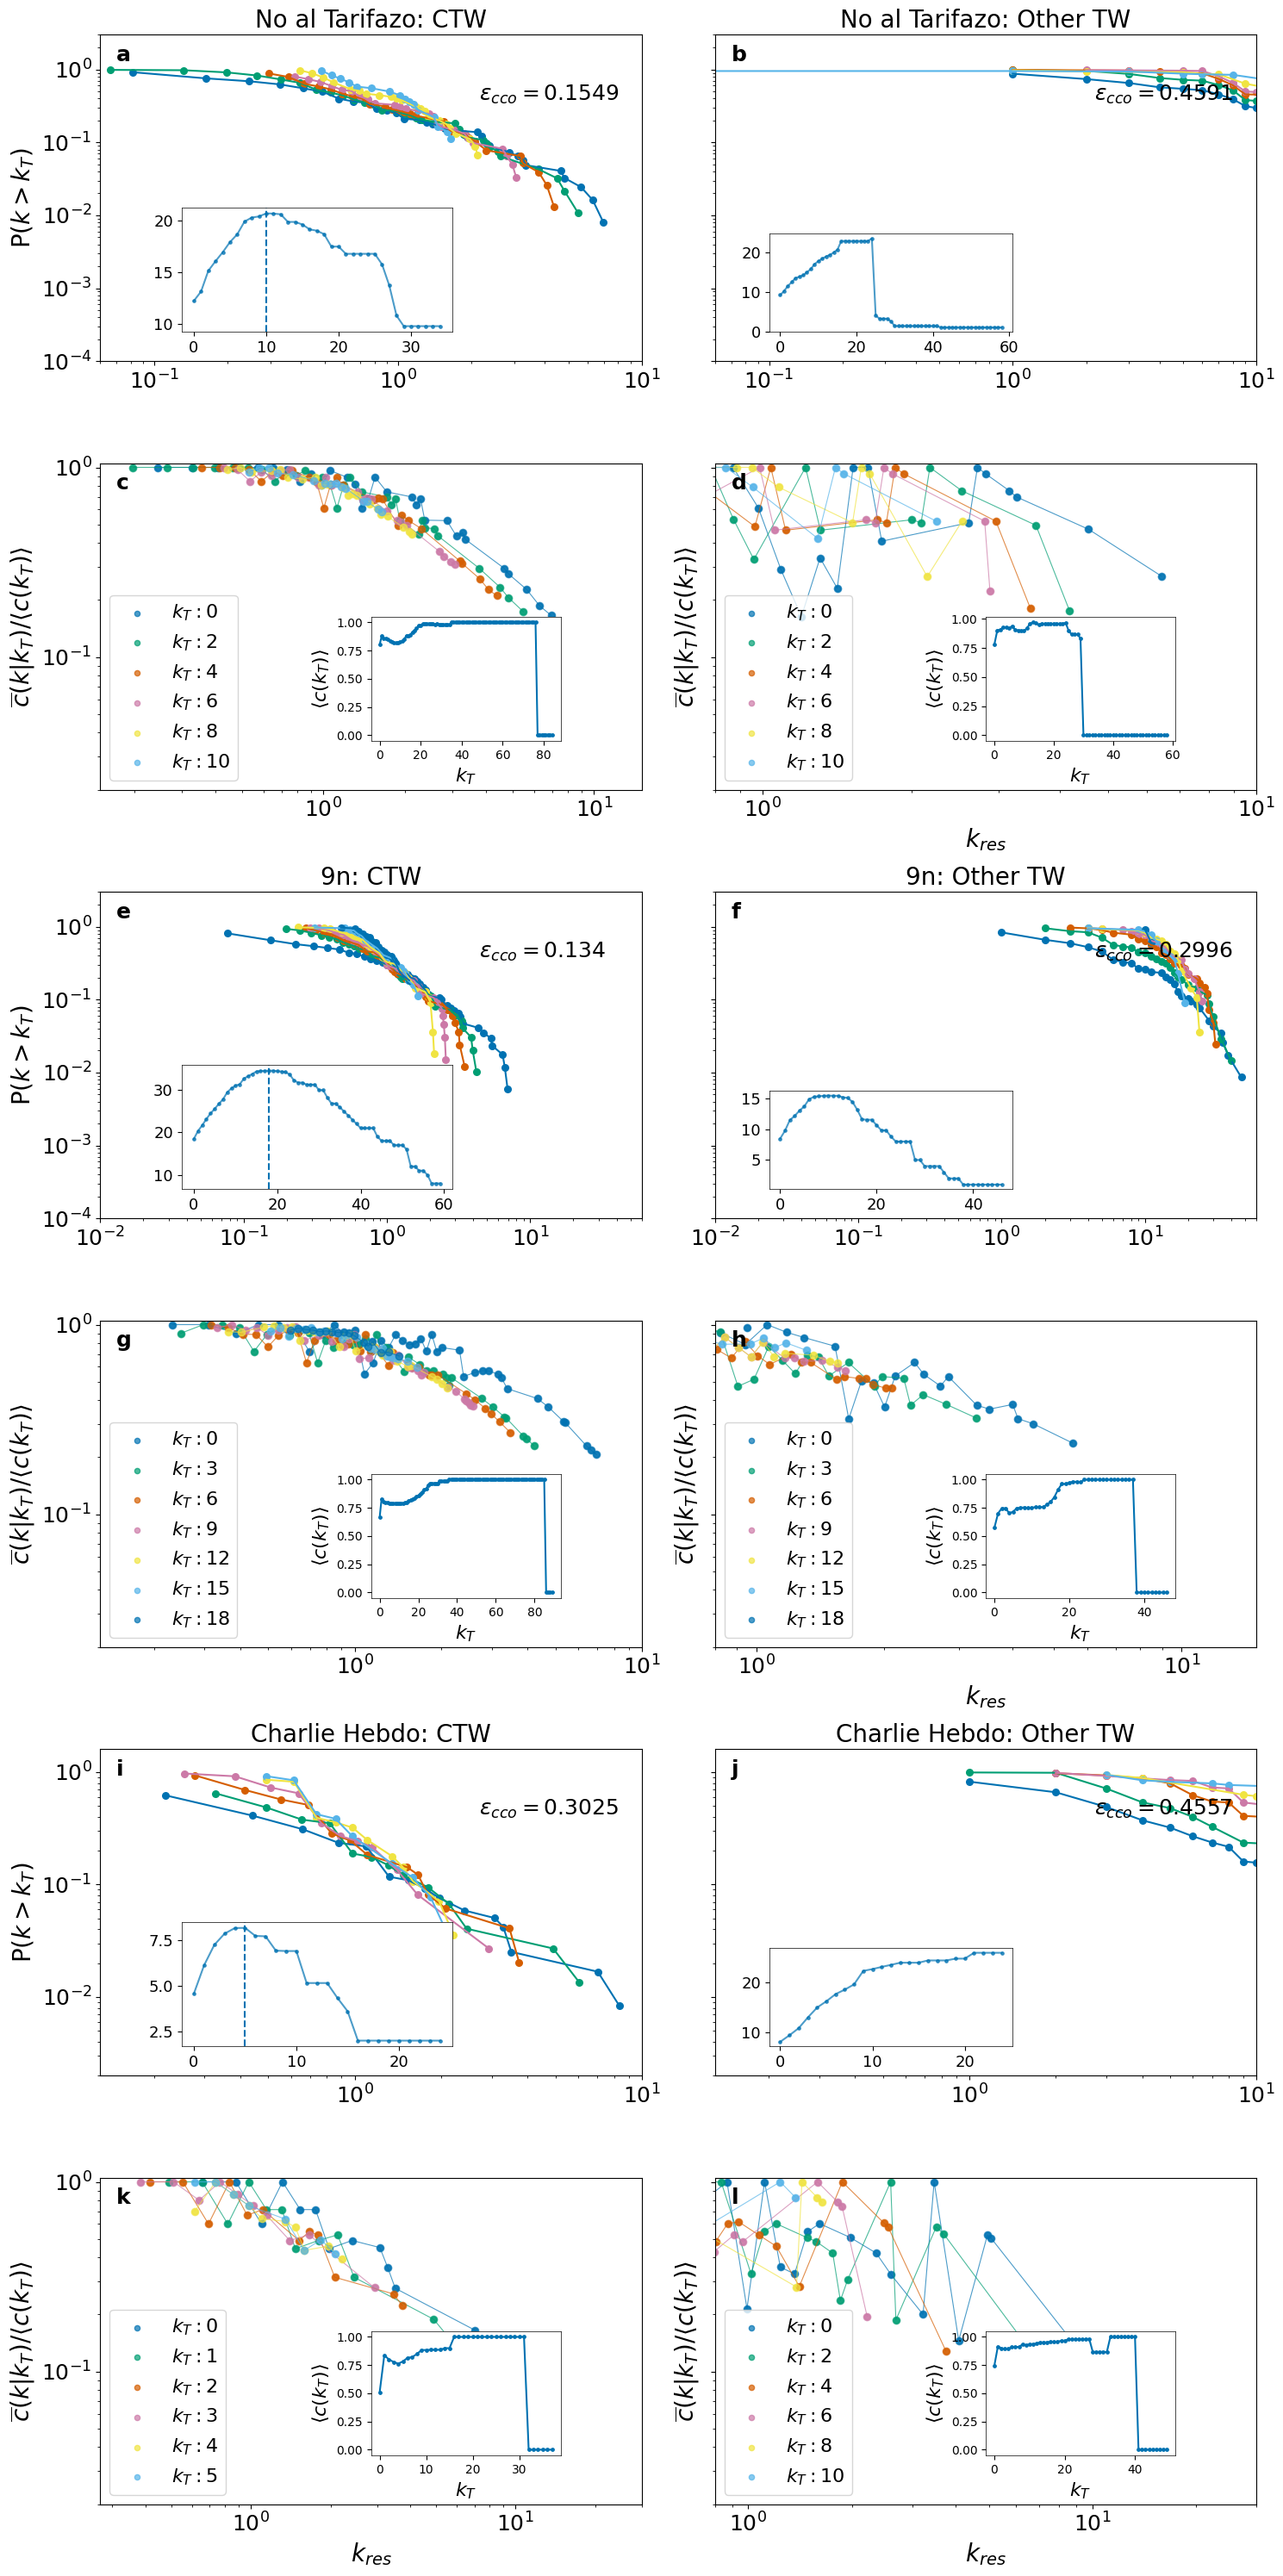

<Figure size 640x480 with 0 Axes>

In [122]:
plt.style.use('seaborn-v0_8-colorblind')
from matplotlib.ticker import MaxNLocator

fig, axs = plt.subplots(6, 2)
axs = axs.flat
for ax in axs: ax.set_facecolor('white')
fig.set_size_inches(15, 30)

cfg = [
    dict(k='nat', title='No al Tarifazo', x_f=(0.15, 15), x_o=(0.8, 10), xcl=100, lim_f='limit_kt_nat_f', lim_o='limit_kt_nat_o_f'),
    dict(k='9n',  title='9n',            x_f=(0.13, 10), x_o=(0.8, 15), xcl=100, lim_f='limit_kt_9n_f',  lim_o='limit_kt_9n_o_f'),
    dict(k='ch',  title='Charlie Hebdo', x_f=(0.27, 30), x_o=(0.8, 30), xcl=50,  lim_f=25,             lim_o=25),
]
G = globals()

def _lim(x):
    return G[x] if isinstance(x, str) else x
	
xlims = [(0.06,10),(0.01,60),(0.13, 10),(0.1,10),(0.0001, 3),(0.9,60),(0.15, 15),(0.1,10),(0.1,10),(0.9, 60),(0.27, 30),(0.1,11)]
ylims = [(0.0001, 3),(0.0001, 3),(0.002, 1.6),(0.002, 1.6),(0.0001, 3),(0.0001, 3),(0.002, 1.6),(0.002, 1.6),(0.002, 1.6),(0.002, 1.6),(0.002, 1.6),(0.002, 1.6)]
for i, c in enumerate(cfg):
    base = 4 * i
    for col, suf, xlim, inset, axv in [
        (0, '_f',   c['x_f'], [0.15, 0.09, 0.5, 0.38], G[f"critical_kt_{c['k']}_f"]),
        (1, '_o_f', c['x_o'], [0.1,  0.09, 0.45, 0.3], None),
    ]:
        ax_pdf, ax_cl = axs[base + col], axs[base + 2 + col]
        arr_ccdf = G[f"arr_ccdf_points_{c['k']}{suf}"]
        arr_kt   = G[f"arr_kt_plot_{c['k']}{suf}"]
        d_deg    = G[f"dict_avg_deg_{c['k']}{suf}"]
        d_int    = G[f"dict_norm_int_deg_{c['k']}{suf}"]
        d_cl     = G[f"dict_thres_avg_clust_{c['k']}{suf}"]
        lim_kt   = _lim(c['lim_f'] if col == 0 else c['lim_o'])



        plot_ccdf(ax_pdf, arr_ccdf, arr_kt,ylim=ylims[i], xlim=xlims[i])
        ax_in = ax_pdf.inset_axes(inset)
        plot_avg_deg(ax_in, d_deg, lim_kt, axvline=axv)
        ax_in.tick_params(axis='both', which='major', labelsize=13)

        plot_clust_ss_densprob_expbin(ax_cl, arr_kt, d_int, aa=1.02, nobinning=0, xlim=xlim, ylim=(0.02, 1.05),
                                     alpha=0.7, marker='o', linewidth=0.8, s=6,
                                     ylabel='$\\overline{c}(k|k_T)/\\langle c(k_T)\\rangle$', xlabel='$k_{res}$')
        ax_in2 = ax_cl.inset_axes([0.5, 0.15, 0.35, 0.38])
        plot_avg_clust(ax_in2, d_cl, ylabel='$\\langle c(k_T)\\rangle$', xlabel='$k_T$', xlim=c['xcl'])




for i, ax in enumerate(axs):
    ax.text(0.03, 0.97, 'abcdefghijkl'[i], transform=ax.transAxes, fontsize=18, fontweight='bold', va='top', ha='left')

for j in [2, 3, 6, 7, 10, 11]: axs[j].legend(fontsize=16, loc='lower left')
for ax in axs: ax.tick_params(axis='both', which='major', labelsize=18)
for j in [0, 4, 8]: axs[j].set_ylabel('P($k>k_T$)', fontsize=20)

for ax_i, eps in [(0, eps_nat), (1, eps_nat_o), (4, eps_9n), (5, eps_9n_o), (8, eps_ch), (9, eps_ch_o)]:
    axs[ax_i].text(0.70, 0.85, '$\\epsilon_{cco}=$' + str(round(eps, 4)), transform=axs[ax_i].transAxes, fontsize=18, va='top', ha='left')

for j in [1, 5, 9]: axs[j].set_ylabel('')
for j in [2, 6]: axs[j].set_xlabel('')
for j in [2, 6, 10]: axs[j].set_ylabel('$\\overline{c}(k|k_T)/\\langle c(k_T)\\rangle$', fontsize=20)
for j in [10, 11]: axs[j].set_xlabel('$k_{res}$', fontsize=20)

axs[0].set_title('No al Tarifazo: CTW', fontsize=20)
axs[1].set_title('No al Tarifazo: Other TW', fontsize=20)
axs[4].set_title('9n: CTW', fontsize=20)
axs[5].set_title('9n: Other TW', fontsize=20)
axs[8].set_title('Charlie Hebdo: CTW', fontsize=20)
axs[9].set_title('Charlie Hebdo: Other TW', fontsize=20)

for j in [1, 3, 5, 7, 9, 11]: axs[j].set_yticklabels([])

plt.tight_layout()
plt.savefig(plots_folder + 'all_self_sim_exponential_o_filtered.png', dpi=300)
plt.show()
axs[2].legend(fontsize=16, loc="lower left")
axs[3].legend(fontsize=16, loc="lower left")
axs[6].legend(fontsize=16, loc="lower left")
axs[7].legend(fontsize=16, loc="lower left")
axs[10].legend(fontsize=16, loc="lower left")
axs[11].legend(fontsize=16, loc="lower left")


for ax in axs:
	ax.tick_params(axis='both', which='major', labelsize=18)  
axs[0].set_ylabel("P($k>k_T$)", fontsize=20)
axs[4].set_ylabel("P($k>k_T$)", fontsize=20)
axs[8].set_ylabel("P($k>k_T$)", fontsize=20)

axs[0].text(0.70, 0.85, "$\epsilon_{cco}=$" + str(round(eps_nat, 4)),transform=axs[0].transAxes, fontsize=18,va="top",ha="left")
axs[1].text(0.70, 0.85, "$\epsilon_{cco}=$" + str(round(eps_nat_o, 4)),transform=axs[1].transAxes, fontsize=18,va="top",ha="left")
axs[4].text(0.70, 0.85, "$\epsilon_{cco}=$" + str(round(eps_9n, 4)),transform=axs[4].transAxes, fontsize=18,va="top",ha="left")
axs[5].text(0.70, 0.85, "$\epsilon_{cco}=$" + str(round(eps_9n_o, 4)),transform=axs[5].transAxes, fontsize=18,va="top",ha="left")
axs[8].text(0.70, 0.85, "$\epsilon_{cco}=$" + str(round(eps_ch, 4)),transform=axs[8].transAxes, fontsize=18,va="top",ha="left")
axs[9].text(0.70, 0.85, "$\epsilon_{cco}=$" + str(round(eps_ch_o, 4)),transform=axs[9].transAxes, fontsize=18,va="top",ha="left")



axs[1].set_ylabel("")
axs[5].set_ylabel("")
axs[9].set_ylabel("")


axs[2].set_xlabel("")
axs[6].set_xlabel("")

axs[2].set_ylabel("$\\overline{c}(k|k_T)/\\langle c(k_T)\\rangle$", fontsize=20)
axs[6].set_ylabel("$\\overline{c}(k|k_T)/\\langle c(k_T)\\rangle$", fontsize=20)
axs[10].set_ylabel("$\\overline{c}(k|k_T)/\\langle c(k_T)\\rangle$", fontsize=20)

axs[10].set_xlabel("$k_{res}$", fontsize=20)
axs[11].set_xlabel("$k_{res}$", fontsize=20)

axs[0].set_title("No al Tarifazo: CTW", fontsize=20)
axs[1].set_title("No al Tarifazo: Other TW", fontsize=20)
axs[4].set_title("9n: CTW", fontsize=20)
axs[5].set_title("9n: Other TW", fontsize=20)
axs[8].set_title("Charlie Hebdo: CTW", fontsize=20)
axs[9].set_title("Charlie Hebdo: Other TW", fontsize=20)

axs[1].set_yticklabels([])
axs[3].set_yticklabels([])
axs[5].set_yticklabels([])
axs[7].set_yticklabels([])
axs[9].set_yticklabels([])
axs[11].set_yticklabels([])

plt.tight_layout()
#plt.savefig(plots_folder + "all_self_sim_exponential_o_filtered.png",dpi=300)
plt.show()

### Unipartite